In [1]:
import sys

import numpy
import pandas
import sklearn

print(sys.version.split()[0], numpy.__version__, pandas.__version__, sklearn.__version__)

3.12.10 2.0.2 2.3.3 1.6.1


# Task 2 — Decision Trees
Gumar Nurtore

SEED = 3242 (last four digits of my student ID).

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 3242

data = pd.read_csv("data/heart_disease.csv")

feature_names = [c for c in data.columns if c != "disease"]

X = data[feature_names].to_numpy()
y = data["disease"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=SEED
)

print(data.shape, round(y.mean(), 3), X_train.shape, X_test.shape)

(297, 14) 0.461 (207, 13) (90, 13)


# Part 1

## Parent entropy

There are 12 patients: 6 with disease and 6 without disease.

p1 = 6/12 = 0.5
p0 = 6/12 = 0.5

H = -(6/12) * log2(6/12) - (6/12) * log2(6/12)
  = -0.5 * (-1) - 0.5 * (-1)
  = 1 bit.

Both classes have the same number of patients, so the entropy is 1.

## Information gain: exercise_angina

Parent entropy = 1 bit.

exercise_angina = 1: 4 patients, all with disease.
H1 = 0.

exercise_angina = 0: 8 patients, 2 with disease and 6 without.
H0 = -(2/8) * log2(2/8) - (6/8) * log2(6/8)
   ≈ 0.811278.

Weighted entropy = (4/12) * 0 + (8/12) * 0.811278
                 ≈ 0.540852.

Information gain = 1 - 0.540852
                 ≈ 0.459148 bits.

## Information gain: other features

### age55
age55 = 1: 5 with disease, 1 without.
age55 = 0: 1 with disease, 5 without.

Both groups have the same entropy:
H = -(5/6) * log2(5/6) - (1/6) * log2(1/6)
  ≈ 0.650022.

IG = 1 - (6/12) * 0.650022 - (6/12) * 0.650022
   ≈ 0.349978.

### male
Both groups have 3 patients with disease and 3 without.

H = -(3/6) * log2(3/6) - (3/6) * log2(3/6)
  = 1.

IG = 1 - (6/12) * 1 - (6/12) * 1 = 0.

### high_bp
high_bp = 1: 4 with disease, 2 without.
high_bp = 0: 2 with disease, 4 without.

Both groups have the same entropy:
H = -(4/6) * log2(4/6) - (2/6) * log2(2/6)
  ≈ 0.918296.

IG = 1 - (6/12) * 0.918296 - (6/12) * 0.918296
   ≈ 0.081704.

## Best root split

| Feature | Information gain |
|---------|------------------|
| exercise_angina | 0.459148 |
| age55 | 0.349978 |
| high_bp | 0.081704 |
| male | 0.000000 |

I choose exercise_angina for the root because it has the highest
information gain.

# Part 2

## Entropy function

In [3]:
def entropy(y):
    """Calculate entropy in bits for a list of class labels."""
    y = np.asarray(y)

    if len(y) == 0:
        return 0.0

    labels, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)

    return float(-np.sum(probabilities * np.log2(probabilities)))

In [4]:
# Проверка
print("All the same:", entropy([0, 0, 0, 0]))
print("Half and half:", entropy([0, 0, 1, 1]))
print("Six zeros, four ones:", entropy([0, 0, 0, 0, 0, 0, 1, 1, 1, 1]))

All the same: -0.0
Half and half: 1.0
Six zeros, four ones: 0.9709505944546686


In [5]:
def information_gain(y, left):
    """Calculate information gain for a split given by a boolean mask."""
    y = np.asarray(y)
    left = np.asarray(left, dtype=bool)

    if len(y) == 0:
        return 0.0

    y_left = y[left]
    y_right = y[~left]

    if len(y_left) == 0 or len(y_right) == 0:
        return 0.0

    weight_left = len(y_left) / len(y)
    weight_right = len(y_right) / len(y)

    entropy_after = (
        weight_left * entropy(y_left)
        + weight_right * entropy(y_right)
    )

    return entropy(y) - entropy_after

In [6]:
# проверка
answers = np.array([1, 1, 0, 0])

good_split = np.array([True, True, False, False])
bad_split = np.array([True, False, True, False])

print("Good split:", information_gain(answers, good_split))
print("Bad split:", information_gain(answers, bad_split))

Good split: 1.0
Bad split: 0.0


In [7]:
def best_split(X, y, min_samples_leaf=1):
    """Return (feature index, threshold, gain), or None if no valid split."""
    X = np.asarray(X)
    y = np.asarray(y)

    best = None
    best_gain = -np.inf

    for feature in range(X.shape[1]):
        values = np.unique(X[:, feature])
        thresholds = (values[:-1] + values[1:]) / 2

        for threshold in thresholds:
            left = X[:, feature] <= threshold

            n_left = np.sum(left)
            n_right = len(y) - n_left

            if n_left < min_samples_leaf or n_right < min_samples_leaf:
                continue

            gain = information_gain(y, left)

            if gain > best_gain:
                best_gain = gain
                best = (feature, float(threshold), float(gain))

    return best

In [8]:
X_example = np.array([[20], [50], [50], [60]])
y_example = np.array([1, 0, 1, 0])

print(best_split(X_example, y_example))

(0, 35.0, 0.31127812445913283)


In [9]:
def build_tree(X, y, max_depth=None, min_samples_leaf=1, depth=0):
    """Build a decision tree using entropy and information gain."""
    X = np.asarray(X)
    y = np.asarray(y)

    labels, counts = np.unique(y, return_counts=True)
    prediction = labels[np.argmax(counts)]

    # Stop if the group is pure or the depth limit is reached.
    if len(labels) == 1 or (max_depth is not None and depth >= max_depth):
        return {"prediction": prediction}

    split = best_split(X, y, min_samples_leaf=min_samples_leaf)

    # Stop if no valid split exists.
    if split is None:
        return {"prediction": prediction}

    feature, threshold, gain = split
    left = X[:, feature] <= threshold

    return {
        "feature": feature,
        "threshold": threshold,
        "gain": gain,
        "prediction": prediction,
        "left": build_tree(
            X[left], y[left], max_depth, min_samples_leaf, depth + 1
        ),
        "right": build_tree(
            X[~left], y[~left], max_depth, min_samples_leaf, depth + 1
        ),
    }

In [10]:
# проверка
small_tree = build_tree(X_example, y_example, max_depth=1)
print(small_tree)

{'feature': 0, 'threshold': 35.0, 'gain': 0.31127812445913283, 'prediction': np.int64(0), 'left': {'prediction': np.int64(1)}, 'right': {'prediction': np.int64(0)}}


In [11]:
def predict_tree(tree, X):
    """Predict class labels for rows in X using our tree."""
    X = np.asarray(X)
    predictions = []

    for patient in X:
        node = tree

        while "feature" in node:
            feature = node["feature"]
            threshold = node["threshold"]

            if patient[feature] <= threshold:
                node = node["left"]
            else:
                node = node["right"]

        predictions.append(node["prediction"])

    return np.array(predictions)

In [12]:
new_patients = np.array([[20], [35], [45], [70]])
print(predict_tree(small_tree, new_patients))

[1 1 0 0]


## Checking the functions on the toy data

In [13]:
toy_data = pd.DataFrame({
    "age55":            [1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0],
    "exercise_angina":  [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    "male":             [1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0],
    "high_bp":          [1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0],
    "disease":          [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
})

toy_data

,age55,exercise_angina,male,high_bp,disease
0,1,1,1,1,1
1,1,1,1,1,1
2,1,1,1,0,1
3,1,1,0,1,1
4,1,0,0,1,1
5,0,0,0,0,1
6,1,0,1,0,0
7,0,0,1,0,0
8,0,0,1,0,0
9,0,0,0,1,0


In [14]:
toy_features = ["age55", "exercise_angina", "male", "high_bp"]

X_toy = toy_data[toy_features].to_numpy()
y_toy = toy_data["disease"].to_numpy()

print("Parent entropy:", entropy(y_toy))

for feature_index, feature_name in enumerate(toy_features):
    left = X_toy[:, feature_index] <= 0.5
    gain = information_gain(y_toy, left)
    print(feature_name, ":", round(gain, 6))

Parent entropy: 1.0
age55 : 0.349978
exercise_angina : 0.459148
male : 0.0
high_bp : 0.081704


In [15]:
toy_best = best_split(X_toy, y_toy)

print("Best split:", toy_best)
print("Feature name:", toy_features[toy_best[0]])

Best split: (1, 0.5, 0.4591479170272448)
Feature name: exercise_angina


In [16]:
# Patients without exercise angina
mask = X_toy[:, 1] == 0

X_branch = X_toy[mask]
y_branch = y_toy[mask]

print("Patients:", len(y_branch))
print("Entropy:", entropy(y_branch))

for i, name in enumerate(toy_features):
    if name == "exercise_angina":
        continue

    left = X_branch[:, i] <= 0.5
    gain = information_gain(y_branch, left)
    print(name, ":", round(gain, 6))

result = best_split(X_branch, y_branch)
print("Best feature:", toy_features[result[0]])

Patients: 8
Entropy: 0.8112781244591328
age55 : 0.073761
male : 0.204434
high_bp : 0.015712
Best feature: male


In [17]:
from sklearn.tree import DecisionTreeClassifier

# Our algorithm
my_split = best_split(X_train, y_train)

print("Our feature:", feature_names[my_split[0]])
print("Our threshold:", my_split[1])
print("Our gain:", my_split[2])

# Scikit-learn algorithm
sk_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=1,
    random_state=SEED
)

sk_tree.fit(X_train, y_train)

print("Sklearn feature:", feature_names[sk_tree.tree_.feature[0]])
print("Sklearn threshold:", sk_tree.tree_.threshold[0])

Our feature: thal
Our threshold: 4.5
Our gain: 0.2227690847093109
Sklearn feature: thal
Sklearn threshold: 4.5


In [18]:
for depth in [1, 2, 3, 4, 5, None]:

    # Our tree
    my_tree = build_tree(X_train, y_train, max_depth=depth)
    my_pred = predict_tree(my_tree, X_test)

    # Sklearn tree
    sk_tree = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=SEED
    )
    sk_tree.fit(X_train, y_train)
    sk_pred = sk_tree.predict(X_test)

    # Compare predictions
    agreement = np.mean(my_pred == sk_pred)

    print("Depth:", depth, "Agreement:", round(agreement, 3))

Depth: 1 Agreement: 1.0
Depth: 2 Agreement: 1.0
Depth: 3 Agreement: 1.0
Depth: 4 Agreement: 1.0
Depth: 5 Agreement: 0.967
Depth: None Agreement: 0.978


### Comparison with scikit-learn

My best_split and scikit-learn selected the same feature
(thal) and the same threshold (4.5).

| Max Depth | Agreement |
|-----------|-----------|
| 1 | 100% |
| 2 | 100% |
| 3 | 100% |
| 4 | 100% |
| 5 | 96.7% |
| None | 97.8% |

Both trees gave the same predictions for depths 1 to 4.

For deeper trees, some predictions were different.
This can happen because the algorithms may choose
different splits when information gains are equal
or very close.

## Part 3 — How Deep Should the Tree Be?

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=SEED
)

scores = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    return_train_score=True
)

print("Train accuracy:", scores["train_score"].mean())
print("CV accuracy:", scores["test_score"].mean())
print("CV std:", scores["test_score"].std())

Train accuracy: 0.8466374589266155
CV accuracy: 0.7631823461091753
CV std: 0.04239877128318833


In [20]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]

results = []

for depth in depths:
    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=SEED
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        return_train_score=True
    )

    model.fit(X_train, y_train)

    results.append({
        "Depth": depth,
        "Leaves": model.get_n_leaves(),
        "Train accuracy": round(scores["train_score"].mean(), 3),
        "CV accuracy": round(scores["test_score"].mean(), 3),
        "CV std": round(scores["test_score"].std(), 3)
    })

depth_results = pd.DataFrame(results)
depth_results

,Depth,Leaves,Train accuracy,CV accuracy,CV std
0,1.0,2,0.775,0.735,0.054
1,2.0,4,0.786,0.730,0.042
2,3.0,7,0.847,0.763,0.042
3,4.0,11,0.889,0.754,0.029
4,5.0,16,0.929,0.758,0.078
5,6.0,22,0.965,0.758,0.052
6,8.0,33,0.993,0.744,0.060
7,10.0,33,0.996,0.763,0.055
8,NaN,33,1.000,0.758,0.042


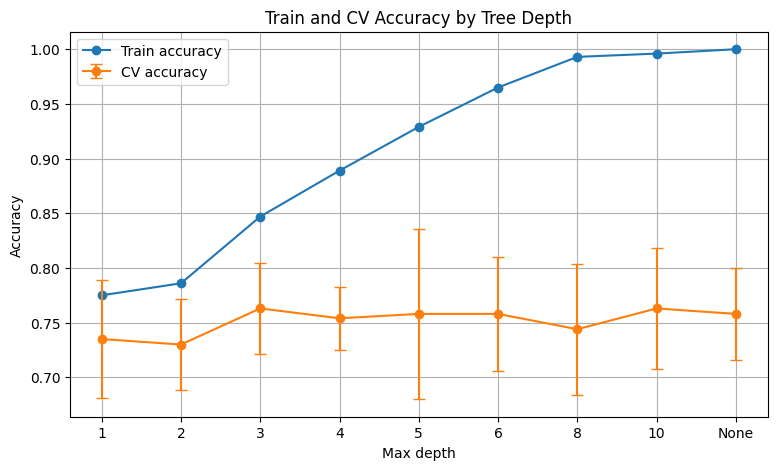

In [21]:
import matplotlib.pyplot as plt

x = range(len(depths))
labels = [str(d) if d is not None else "None" for d in depths]

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    depth_results["Train accuracy"],
    marker="o",
    label="Train accuracy"
)

plt.errorbar(
    x,
    depth_results["CV accuracy"],
    yerr=depth_results["CV std"],
    marker="o",
    capsize=4,
    label="CV accuracy"
)

plt.xticks(x, labels)
plt.xlabel("Max depth")
plt.ylabel("Accuracy")
plt.title("Train and CV Accuracy by Tree Depth")
plt.legend()
plt.grid(True)
plt.show()

### Choosing the best depth

I use the one-standard-error rule.

First, I find the highest mean CV accuracy.
Then I choose the smallest depth with CV accuracy
within one standard error of the best result.

This helps me choose a simpler tree.

In [22]:
cv_means = []
cv_stds = []

for depth in depths:
    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=SEED
    )

    scores = cross_validate(
        model, X_train, y_train,
        cv=cv, scoring="accuracy"
    )

    cv_means.append(scores["test_score"].mean())
    cv_stds.append(scores["test_score"].std())

best_i = np.argmax(cv_means)
best_mean = cv_means[best_i]

best_se = cv_stds[best_i] / np.sqrt(5)
limit = best_mean - best_se

for depth, mean in zip(depths, cv_means):
    if mean >= limit:
        chosen_depth = depth
        break

print("Best CV accuracy:", round(best_mean, 4))
print("One-SE limit:", round(limit, 4))
print("Chosen depth:", chosen_depth)

Best CV accuracy: 0.7632
One-SE limit: 0.7442
Chosen depth: 3


I chose max_depth = 3 using the one-standard-error rule.

The best CV accuracy is 0.7632, and the limit is 0.7442. Depth 3 is the smallest depth above this limit.

Depths 4 and 5 have similar results. The differences are small compared to the CV standard deviation, so depth 3 is not clearly better than nearby depths.

I chose depth 3 because it is simple and has good CV accuracy. 

Why not?

In [23]:
leaf_sizes = [1, 2, 5, 10, 20, 40]

leaf_results = []

for leaf_size in leaf_sizes:
    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=None,
        min_samples_leaf=leaf_size,
        random_state=SEED
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        return_train_score=True
    )

    model.fit(X_train, y_train)

    leaf_results.append({
        "Min leaf": leaf_size,
        "Leaves": model.get_n_leaves(),
        "Train accuracy": round(scores["train_score"].mean(), 3),
        "CV accuracy": round(scores["test_score"].mean(), 3),
        "CV std": round(scores["test_score"].std(), 3)
    })

leaf_results = pd.DataFrame(leaf_results)
leaf_results

,Min leaf,Leaves,Train accuracy,CV accuracy,CV std
0,1,33,1.000,0.758,0.042
1,2,29,0.958,0.743,0.081
2,5,20,0.899,0.768,0.043
3,10,12,0.860,0.778,0.052
4,20,8,0.783,0.730,0.042
5,40,4,0.775,0.735,0.054


### Comparing Two Ways to Limit a Tree

Max depth limits how deep the tree can grow, while min_samples_leaf limits how small its leaf groups can be.

With min_samples_leaf = 10  the CV accuracy was 0.778, which was a little higher than 0.763 for depth 3. But the difference is small compared to the CV standard deviations, so I kept depth 3 as my selected model

In [24]:
final_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=chosen_depth,
    random_state=SEED
)

final_tree.fit(X_train, y_train)

test_pred = final_tree.predict(X_test)

test_accuracy = np.mean(test_pred == y_test)
n = len(y_test)

test_se = np.sqrt(test_accuracy * (1 - test_accuracy) / n)

print("Chosen depth:", chosen_depth)
print("Test patients:", n)
print("Test accuracy:", round(test_accuracy, 4))
print("Standard error:", round(test_se, 4))

Chosen depth: 3
Test patients: 90
Test accuracy: 0.8
Standard error: 0.0422


### Final Test Result

I selected a decision tree with max_depth = 3.

The test accuracy is 0.80 (80%). The model predicted 72 out of 90 test patients correctly.

The standard error is 0.0422. This means the test accuracy has some uncertainty because the test set is small.

The unlimited tree had 100% training accuracy but only 75.8% mean CV accuracy. This shows overfitting.

I kept depth 3 because it is simpler and has similar CV accuracy to deeper trees.


## Part 4 — Tree or Logistic Regression?

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

scores = cross_validate(
    logreg,
    X_train,
    y_train,
    cv=cv,
    scoring=("accuracy", "f1")
)

print("CV accuracy:", round(scores["test_accuracy"].mean(), 4))
print("CV std:", round(scores["test_accuracy"].std(), 4))
print("CV F1:", round(scores["test_f1"].mean(), 4))

CV accuracy: 0.8354
CV std: 0.0743
CV F1: 0.8131


In [26]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

models = {
    "Chosen tree": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=chosen_depth,
        random_state=SEED
    ),
    "Unlimited tree": DecisionTreeClassifier(
        criterion="entropy",
        random_state=SEED
    ),
    "Logistic regression": logreg
}

comparison = []

for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train,
        cv=cv, scoring=("accuracy", "f1")
    )

    comparison.append({
        "Model": name,
        "CV accuracy": round(scores["test_accuracy"].mean(), 4),
        "CV std": round(scores["test_accuracy"].std(), 4),
        "CV F1": round(scores["test_f1"].mean(), 4)
    })

comparison_df = pd.DataFrame(comparison)
comparison_df

,Model,CV accuracy,CV std,CV F1
0,Chosen tree,0.7632,0.0424,0.7321
1,Unlimited tree,0.7583,0.0415,0.7405
2,Logistic regression,0.8354,0.0743,0.8131


In [27]:
# Tree without scaling
tree1 = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=chosen_depth,
    random_state=SEED
)

tree1.fit(X_train, y_train)
pred1 = tree1.predict(X_test)

# Tree with scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

tree2 = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=chosen_depth,
    random_state=SEED
)

tree2.fit(X_train_scaled, y_train)
pred2 = tree2.predict(X_test_scaled)

agreement = np.mean(pred1 == pred2)

print("Scaling agreement:", round(agreement, 4))

Scaling agreement: 1.0


In [28]:
final_models = {
    "Decision Tree": tree1,
    "Logistic Regression": logreg
}

for name, model in final_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    se = np.sqrt(acc * (1 - acc) / len(y_test))

    print("\n", name)
    print("Test accuracy:", round(acc, 4))
    print("Test F1:", round(f1, 4))
    print("Standard error:", round(se, 4))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, pred))


 Decision Tree
Test accuracy: 0.8
Test F1: 0.7568
Standard error: 0.0422
Confusion matrix:
[[44  4]
 [14 28]]

 Logistic Regression
Test accuracy: 0.8333
Test F1: 0.8193
Standard error: 0.0393
Confusion matrix:
[[41  7]
 [ 8 34]]


### Part 4(a) — Model Comparison

| Model | CV Accuracy | CV Std | CV F1 |
|---|---|---|---|
| Chosen Tree | 0.7632 | 0.0424 | 0.7321 |
| Unlimited Tree | 0.7583 | 0.0415 | 0.7405 |
| Logistic Regression | 0.8354 | 0.0743 | 0.8131 |

Logistic regression had the highest mean CV accuracy and F1 score. The unlimited tree did not perform better than the chosen tree in CV accuracy.

### Part 4(b) — Scaling

The scaling agreement was 1.0 (100%).

Decision trees do not usually need scaling because scaling does not change the order of feature values. The tree can make the same splits with different thresholds.

### Part 4(c) — Test Results

**Decision Tree:**
- Accuracy: 0.8000
- F1: 0.7568
- Standard error: 0.0422
- Confusion matrix: [[44, 4], [14, 28]]

**Logistic Regression:**
- Accuracy: 0.8333
- F1: 0.8193
- Standard error: 0.0393
- Confusion matrix: [[41, 7], [8, 34]]

### Part 4(d) — Conclusion

I would choose logistic regression for this dataset. It had higher mean CV accuracy (0.8354) than the chosen tree (0.7632). It also had better test accuracy and F1 score. However, the CV results have some spread, and the test standard errors are about 0.04. The test accuracy difference of 0.0333 is small, so I cannot be sure that logistic regression is always better. I would need more data to compare the models with more confidence.

## Part 5 — Reading a Tree and Reproducibility

In [29]:
from sklearn.tree import export_text, plot_tree

shallow = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=SEED
)

shallow.fit(X_train, y_train)

print(export_text(shallow, feature_names=feature_names))

|--- thal <= 4.50
|   |--- age <= 45.50
|   |   |--- class: 0
|   |--- age >  45.50
|   |   |--- oldpeak <= 2.80
|   |   |   |--- class: 0
|   |   |--- oldpeak >  2.80
|   |   |   |--- class: 1
|--- thal >  4.50
|   |--- ca <= 0.50
|   |   |--- exang <= 0.50
|   |   |   |--- class: 0
|   |   |--- exang >  0.50
|   |   |   |--- class: 1
|   |--- ca >  0.50
|   |   |--- slope <= 1.50
|   |   |   |--- class: 1
|   |   |--- slope >  1.50
|   |   |   |--- class: 1



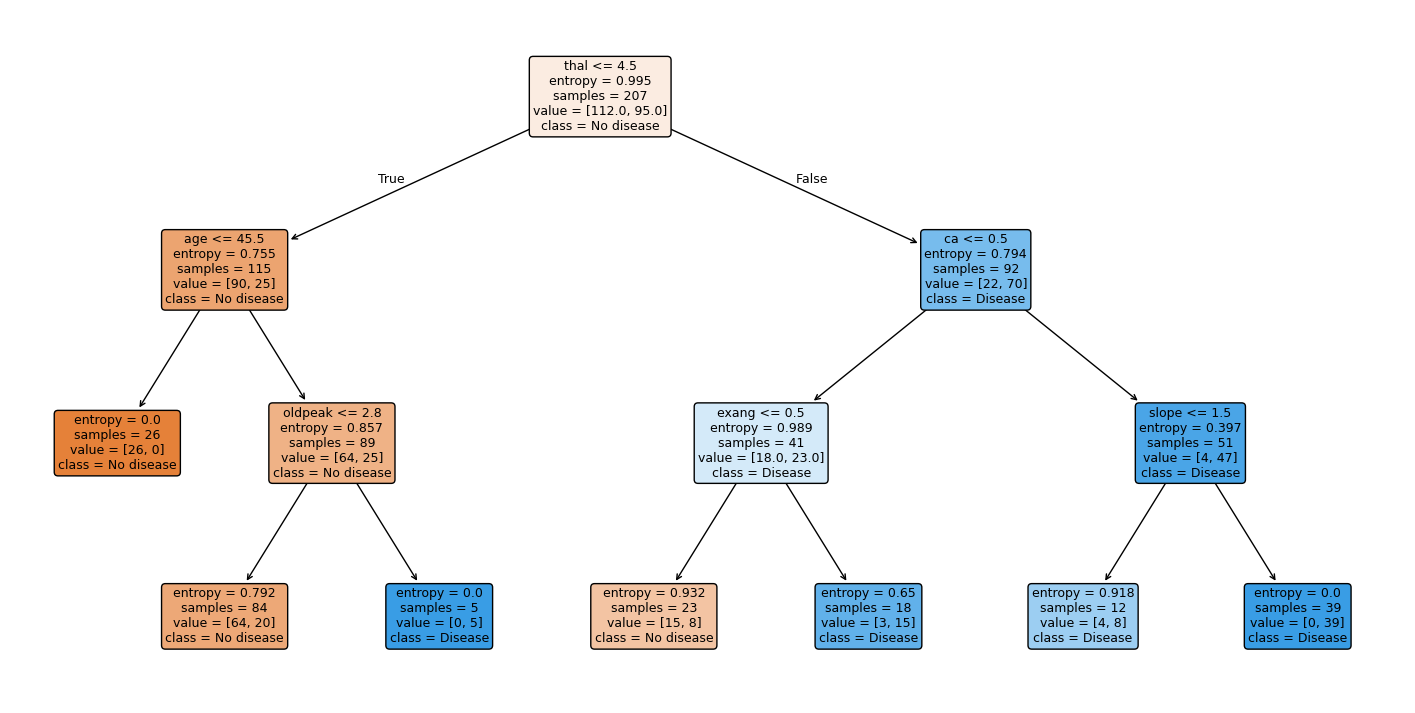

In [30]:
plt.figure(figsize=(18, 9))

plot_tree(
    shallow,
    feature_names=feature_names,
    class_names=["No disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.show()

In [31]:
ranked = sorted(
    zip(shallow.feature_importances_, feature_names),
    reverse=True
)

print("Top 5 features:")

for importance, name in ranked[:5]:
    print(name, ":", round(float(importance), 3))

Top 5 features:
thal : 0.484
ca : 0.128
age : 0.111
oldpeak : 0.102
slope : 0.097


### Same Class on Both Sides

A tree can split into two groups that predict the same class. This happens because the tree tries to reduce entropy, not only change the predicted class. The split can make the groups more pure and help with later splits.

### Part 5(a) — Two Rules

**Rule 1 — No Disease**

If thal is 4.5 or less and age is 45.5 or less, the tree predicts no disease. There are 26 training patients in this leaf.

**Rule 2 — Disease**

If thal is more than 4.5, ca is more than 0.5, and slope is more than 1.5, the tree predicts disease. There are 39 training patients in this leaf.

### Part 5(b) — Feature Importance

The five most important features are:

1. thal — 0.484
2. ca — 0.128
3. age — 0.111
4. oldpeak — 0.102
5. slope — 0.097

Feature importance shows which features help the tree reduce entropy. But it does not mean that a feature causes the disease.

### Part 5(c) — Same Class on Both Sides

A tree can split into two groups that predict the same class. This happens because the tree tries to reduce entropy, not only change the predicted class.

For example, the slope split has two children that both predict disease. But one child is more pure, so the split is still useful.